# Notebook 06: Modelado Físico de Esfuerzos de Marea (Criterio de Coulomb)
**Autor:** Iván Andrés Mena Contreras
**Proyecto:** Lunar Tidal Triggering of Earthquakes

Tras la recomendación del *peer review* geofísico, pivoteamos nuestro modelo mecánico. La influencia gravitacional puramente geométrica (distancia o derivadas escalares) no es suficiente, ya que la **fuerza de marea** decae con el cubo de la distancia ($1/r^3$). 

**Objetivos:**
1. Calcular la Amplitud Real de Marea proporcional a $1/r^3$.
2. Descomponerla en tensores topocéntricos: **Normal** (descompresión vertical) y **Cortante** (cizalladura paralela).
3. Evaluar el Cambio de Estrés de Falla de Coulomb ($\Delta \text{CFS}$) asumiendo fricción estática ($\mu=0.4$) para observar si la suma de estas fuerzas favorecía físicamente la ruptura en el instante del sismo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skyfield.api import load, wgs84
from tqdm import tqdm
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('../results/figures', exist_ok=True)

# Cargar dataset base (el que contiene los lags y los 335 sismos M>=7.0)
data_path = '../data/processed/earthquakes_lag_analysis.csv'
df = pd.read_csv(data_path)
df['time'] = pd.to_datetime(df['time'], format='mixed', utc=True)

print(f"Catálogo cargado: {len(df)} eventos de subducción global.")

Catálogo cargado: 56 eventos de subducción global.


## 1. Topocentrismo y Amplitud $1/r^3$
Calculamos la posición aparente lunar vista desde el hipocentro exacto. La fuerza es proporcional a $1 / \text{distancia}^3$. Normalizaremos esta variable en un índice $A_{norm} \in [0,1]$.

In [2]:
ts = load.timescale()
eph = load('de421.bsp')
tierra, luna = eph['earth'], eph['moon']

df['moon_altitude'] = np.nan
df['distancia_real_km'] = np.nan

print("Calculando vectores de Skyfield y Amplitud Gravitacional...")
for idx, row in tqdm(df.iterrows(), total=len(df)):
    t = ts.from_datetime(row['time'])
    
    # Observador subterráneo en el hipocentro
    elev_m = -row['depth'] * 1000
    obs = tierra + wgs84.latlon(row['latitude'], row['longitude'], elevation_m=elev_m)
    
    astrometric = obs.at(t).observe(luna)
    alt, az, dist = astrometric.apparent().altaz()
    
    df.loc[idx, 'moon_altitude'] = alt.degrees
    df.loc[idx, 'distancia_real_km'] = dist.km

# 1. Fuerza proporcional a 1/r^3
amplitud_cruda = 1.0 / (df['distancia_real_km'] ** 3)

# 2. Normalización de [0 a 1] dividiendo por el máximo teórico del catálogo
df['A_norm'] = amplitud_cruda / amplitud_cruda.max()

print("Cálculo de Altitud y $A_{norm}$ completado.")
df[['moon_altitude', 'distancia_real_km', 'A_norm']].head()

Calculando vectores de Skyfield y Amplitud Gravitacional...


  0%|          | 0/56 [00:00<?, ?it/s]

 79%|███████▊  | 44/56 [00:00<00:00, 434.44it/s]

100%|██████████| 56/56 [00:00<00:00, 433.38it/s]

Cálculo de Altitud y $A_{norm}$ completado.


,moon_altitude,distancia_real_km,A_norm
0,33.450662,400198.585426,0.715064
1,6.453201,361693.164858,0.968614
2,-12.840886,375657.936873,0.864557
3,60.294798,357868.802366,1.000000
4,79.254533,398717.088316,0.723064


## 2. Esfuerzos Tensoriales y Criterio de Coulomb ($\Delta$CFS)
Con el vector definido por la altitud y la amplitud, proyectamos el esfuerzo:
- **Esfuerzo Cortante ($\tau$):** Promueve deslizamiento paralelo al plano. $\tau = A_{norm} \cdot \cos(\text{Altitud})$
- **Esfuerzo Normal ($\sigma_n$):** Promueve la descompresión ortogonal al plano (*unclamping*). $\sigma_n = A_{norm} \cdot \sin(\text{Altitud})$

El **Criterio de Falla de Coulomb** dicta que el estrés de falla ($\Delta \text{CFS}$) se rige por:
$$ \Delta \text{CFS} = \tau + \mu \cdot \sigma_n $$
Donde $\mu = 0.4$ es un coeficiente de fricción estática crustal promedio.

In [3]:
alt_rad = np.radians(df['moon_altitude'])

# Tensores 
df['tau'] = df['A_norm'] * np.cos(alt_rad)
df['sigma_n'] = df['A_norm'] * np.sin(alt_rad)

# Delta Coulomb Failure Stress
mu = 0.4
df['delta_cfs'] = df['tau'] + (mu * df['sigma_n'])

print("Cálculo de tensores y Delta CFS finalizado.")

Cálculo de tensores y Delta CFS finalizado.


## 3. Evaluación Mecánica del Sistema
Si las fuerzas de marea están desencadenando los sismos, esperaríamos ver una asimetría hacia valores positivos de $\Delta \text{CFS}$ (que favorecen la ruptura) en lugar de una campana gaussiana perfectamente centrada en cero.

Gráficas físicas guardadas en: ../results/figures/06_coulomb_analysis.png


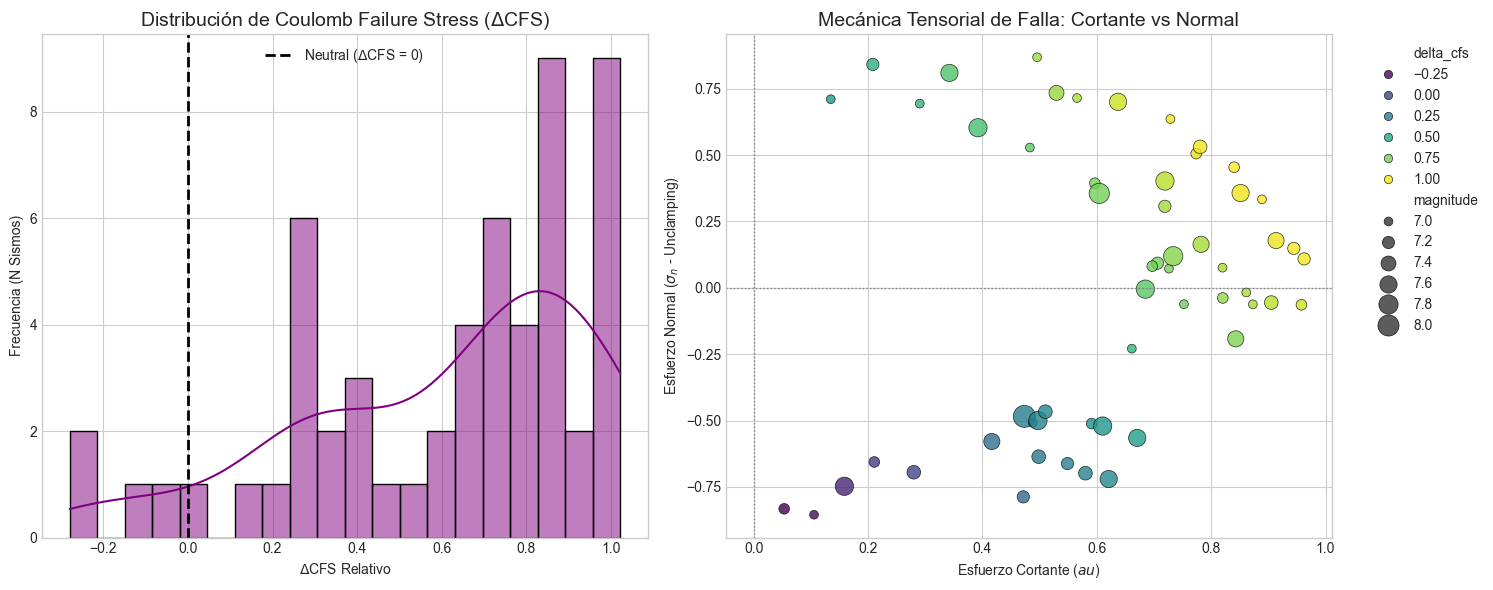

In [4]:
fig = plt.figure(figsize=(15, 6))

# GRÁFICO A: Distribución del Delta CFS
ax1 = plt.subplot(1, 2, 1)
sns.histplot(df['delta_cfs'], bins=20, kde=True, color='purple', ax=ax1)
ax1.axvline(0, color='black', linestyle='--', linewidth=2, label='Neutral ($\Delta$CFS = 0)')
ax1.set_title('Distribución de Coulomb Failure Stress ($\Delta$CFS)', fontsize=14)
ax1.set_xlabel('$\Delta$CFS Relativo')
ax1.set_ylabel('Frecuencia (N Sismos)')
ax1.legend()

# GRÁFICO B: Tensores Cortante vs Normal
ax2 = plt.subplot(1, 2, 2)
scatter = sns.scatterplot(
    data=df, x='tau', y='sigma_n',
    hue='delta_cfs', size='magnitude', sizes=(40, 250),
    palette='viridis', alpha=0.8, edgecolor='k', ax=ax2
)
ax2.axhline(0, color='grey', linewidth=1, linestyle=':')
ax2.axvline(0, color='grey', linewidth=1, linestyle=':')
ax2.set_title('Mecánica Tensorial de Falla: Cortante vs Normal', fontsize=14)
ax2.set_xlabel('Esfuerzo Cortante ($\tau$)')
ax2.set_ylabel('Esfuerzo Normal ($\sigma_n$ - Unclamping)')

# Extraer leyenda de tamaño y moverla
handles, labels = scatter.get_legend_handles_labels()
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

# Guardar figura
fig_path = '../results/figures/06_coulomb_analysis.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Gráficas físicas guardadas en: {fig_path}")
plt.show()

## 4. Exportar Modelado Final
Almacenamos la tabla para tener listos los componentes de Coulomb en la siguiente fase analítica.

In [5]:
export_path = '../data/processed/earthquakes_coulomb_physics.csv'
df.to_csv(export_path, index=False)
print(f"Dataset de física de Coulomb exportado exitosamente a: {export_path}")

Dataset de física de Coulomb exportado exitosamente a: ../data/processed/earthquakes_coulomb_physics.csv
